# Bài thực hành: Logistic Regression, kNN, Decision Tree, Random Forest


## Bước 1. Khởi tạo môi trường

In [1]:
from pathlib import Path
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

MSSV = "24678681"
SEED = 42
np.random.seed(SEED)

ROOT = Path(".")
OUT = ROOT / "outputs"
MODELS = ROOT / "models"
OUT.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

print("Seed:", SEED)
print("Output:", OUT.resolve())
print("Models:", MODELS.resolve())

Seed: 42
Output: T:\24678681_LaiBaTrung\24678681_TH_PhanLoai\24678681_TH_PhanLoai - Copy\24678681_TH_PhanLoai\outputs
Models: T:\24678681_LaiBaTrung\24678681_TH_PhanLoai\24678681_TH_PhanLoai - Copy\24678681_TH_PhanLoai\models


## Bước 2. Đọc dữ liệu và mã hóa lớp dương

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series((data.target == 0).astype(int), name="target")
df = X.copy()
df["target"] = y
df["target_name"] = y.map({1: "malignant", 0: "benign"})

print("X shape:", X.shape)
print("df shape:", df.shape)

X shape: (569, 30)
df shape: (569, 32)


In [3]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,malignant


In [4]:
df.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.256,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,1,malignant
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.463,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,1,malignant
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.075,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,1,malignant
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.595,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,1,malignant
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,0.3857,1.428,2.548,19.15,0.007189,0.00466,0.00000,0.00000,0.02676,0.002783,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,0,benign


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [7]:
total_missing = X.isnull().sum().sum()
duplicated_rows = X.duplicated().sum()
class_counts = df["target_name"].value_counts()

print("Total missing values:", total_missing)
print("Duplicated rows:", duplicated_rows)
print(class_counts)

Total missing values: 0
Duplicated rows: 0
benign       357
malignant    212
Name: target_name, dtype: int64


In [8]:
overview_rows = []
for col in X.columns:
    overview_rows.append({
        "feature": col,
        "dtype": str(X[col].dtype),
        "missing_count": int(X[col].isnull().sum()),
        "unique_count": int(X[col].nunique()),
        "mean": X[col].mean(),
        "std": X[col].std(),
        "min": X[col].min(),
        "max": X[col].max()
    })
data_overview = pd.DataFrame(overview_rows)
data_overview.to_csv(OUT / "01_data_overview.csv", index=False)
data_overview

,feature,dtype,missing_count,unique_count,mean,std,min,max
0,mean radius,float64,0,456,14.127292,3.524049,6.981000,28.11000
1,mean texture,float64,0,479,19.289649,4.301036,9.710000,39.28000
2,mean perimeter,float64,0,522,91.969033,24.298981,43.790000,188.50000
3,mean area,float64,0,539,654.889104,351.914129,143.500000,2501.00000
4,mean smoothness,float64,0,474,0.096360,0.014064,0.052630,0.16340
5,mean compactness,float64,0,537,0.104341,0.052813,0.019380,0.34540
6,mean concavity,float64,0,537,0.088799,0.079720,0.000000,0.42680
7,mean concave points,float64,0,542,0.048919,0.038803,0.000000,0.20120
8,mean symmetry,float64,0,432,0.181162,0.027414,0.106000,0.30400
9,mean fractal dimension,float64,0,499,0.062798,0.007060,0.049960,0.09744


**Nhận xét:** Bộ dữ liệu gồm 569 mẫu và 30 đặc trưng số học (`X`), `df` sau khi thêm `target` và `target_name` có 32 cột đúng như yêu cầu. Toàn bộ đặc trưng đều là kiểu `float64`, không có cột phân loại dạng chuỗi trong `X`. Không phát hiện giá trị thiếu (`total_missing = 0`) và không có dòng trùng lặp (`duplicated_rows = 0`), cho thấy dữ liệu có chất lượng tốt, không cần xử lý làm sạch phức tạp. Về phân bố lớp, `benign` (357 mẫu) nhiều hơn `malignant` (212 mẫu), tỷ lệ khoảng 1.68:1 — mất cân bằng nhẹ nhưng chưa nghiêm trọng. Giá trị `1` trong `y` được xác nhận đúng là `malignant` vì được tạo từ điều kiện `data.target == 0` (0 vốn là mã malignant gốc của Scikit-learn). Vì `unique_count` của mọi đặc trưng đều lớn hơn 2 và không có `missing_count`, dữ liệu sẵn sàng để đưa vào các bước EDA và mô hình hóa tiếp theo.

## Bước 3. EDA có mục tiêu
### 02_class_distribution.png

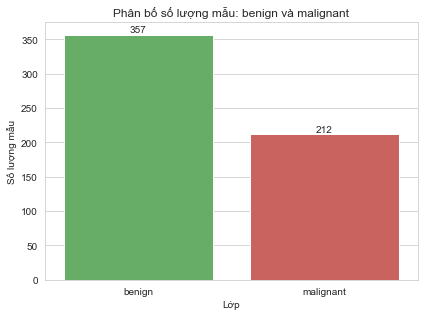

In [9]:
fig, ax = plt.subplots(figsize=(6, 4.5))
order = ["benign", "malignant"]
sns.countplot(x=df["target_name"], order=order, palette=["#5cb85c", "#d9534f"], ax=ax)
ax.set_title("Phân bố số lượng mẫu: benign và malignant")
ax.set_xlabel("Lớp")
ax.set_ylabel("Số lượng mẫu")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.savefig(OUT / "02_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Nhận xét:** Số mẫu `benign` (357) nhiều hơn đáng kể so với `malignant` (212), chênh lệch khoảng 145 mẫu. Vì lớp dương (`malignant`) là lớp thiểu số, Accuracy có thể chưa đủ để đánh giá mô hình: một mô hình luôn dự đoán `benign` vẫn đạt Accuracy khoảng 62.7% dù hoàn toàn vô dụng trong việc phát hiện ca ác tính, do đó cần dùng thêm Precision, Recall, F1 và ROC-AUC của lớp `malignant`.

### 03_feature_distributions.png

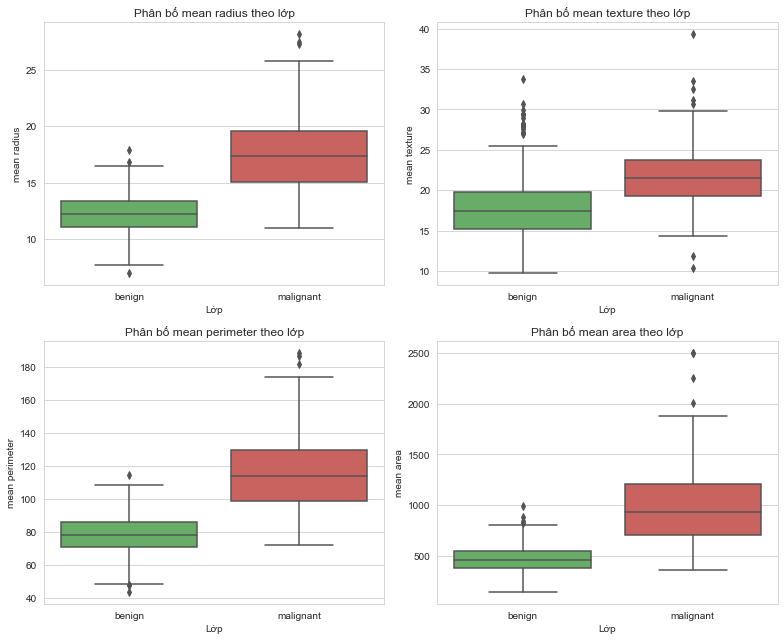

In [10]:
features_to_plot = ["mean radius", "mean texture", "mean perimeter", "mean area"]
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()
for i, feat in enumerate(features_to_plot):
    sns.boxplot(x=df["target_name"], order=order, y=df[feat], palette=["#5cb85c", "#d9534f"], ax=axes[i])
    axes[i].set_title(f"Phân bố {feat} theo lớp")
    axes[i].set_xlabel("Lớp")
    axes[i].set_ylabel(feat)
plt.tight_layout()
plt.savefig(OUT / "03_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

**Nhận xét:** `mean radius`, `mean perimeter` và `mean area` tách hai lớp khá rõ ràng — nhóm `malignant` có trung vị và tứ phân vị cao hơn hẳn nhóm `benign` với phần chồng lấn tương đối hẹp. Ngược lại, `mean texture` có mức chồng lấn lớn hơn giữa hai lớp, cho thấy đây là đặc trưng phân tách yếu hơn so với ba đặc trưng còn lại khi xét riêng lẻ.

### 04_correlation_heatmap.png

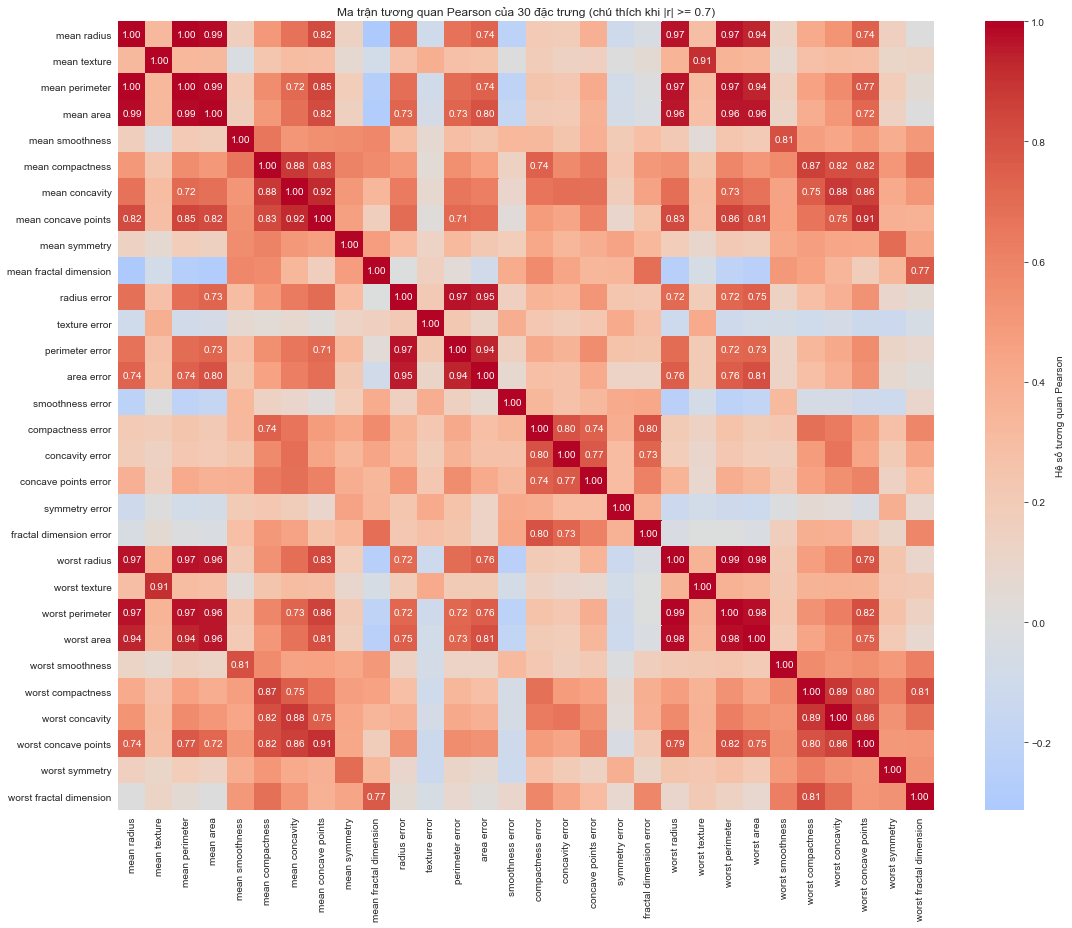

In [11]:
corr_matrix = X.corr()
annot_values = [
    [f"{v:.2f}" if pd.notnull(v) and abs(v) >= 0.7 else "" for v in row]
    for row in corr_matrix.values
]
annot_labels = pd.DataFrame(annot_values, index=corr_matrix.index, columns=corr_matrix.columns)

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=annot_labels, fmt="", ax=ax,
            cbar_kws={"label": "Hệ số tương quan Pearson"})
ax.set_title("Ma trận tương quan Pearson của 30 đặc trưng (chú thích khi |r| >= 0.7)")
plt.tight_layout()
plt.savefig(OUT / "04_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack()
top_corr_pairs = corr_pairs.abs().sort_values(ascending=False).head(10)
top_corr_pairs

mean radius      mean perimeter     0.997855
worst radius     worst perimeter    0.993708
mean radius      mean area          0.987357
mean perimeter   mean area          0.986507
worst radius     worst area         0.984015
worst perimeter  worst area         0.977578
radius error     perimeter error    0.972794
mean perimeter   worst perimeter    0.970387
mean radius      worst radius       0.969539
mean perimeter   worst radius       0.969476
dtype: float64

**Nhận xét:** Ba cặp đặc trưng có tương quan cao đáng chú ý là `mean radius` với `mean perimeter`, `mean radius` với `mean area`, và `mean perimeter` với `mean area` (đều có |r| xấp xỉ 1.0 vì đây là các đại lượng hình học phụ thuộc lẫn nhau). Tương tự, các đặc trưng ở mức "worst" và "mean" của cùng một chỉ số (ví dụ `worst radius` với `mean radius`) cũng có tương quan rất cao. Đây chỉ là quan hệ thống kê phản ánh sự phụ thuộc toán học hoặc đo lường giữa các đặc trưng, hoàn toàn không hàm ý quan hệ nhân quả với biến mục tiêu hay giữa các đặc trưng với nhau.

## Bước 4. Chia train/test

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


In [14]:
split_summary = {
    "seed": SEED,
    "test_size": 0.20,
    "positive_class": "malignant",
    "n_train": int(X_train.shape[0]),
    "n_test": int(X_test.shape[0]),
    "train_class_counts": {
        "malignant": int((y_train == 1).sum()),
        "benign": int((y_train == 0).sum())
    },
    "test_class_counts": {
        "malignant": int((y_test == 1).sum()),
        "benign": int((y_test == 0).sum())
    }
}
with open(OUT / "05_split_summary.json", "w", encoding="utf-8") as f:
    json.dump(split_summary, f, indent=2, ensure_ascii=False)

split_summary

{'seed': 42,
 'test_size': 0.2,
 'positive_class': 'malignant',
 'n_train': 455,
 'n_test': 114,
 'train_class_counts': {'malignant': 170, 'benign': 285},
 'test_class_counts': {'malignant': 42, 'benign': 72}}

**Giải thích:** `stratify=y` đảm bảo tỷ lệ giữa `malignant` và `benign` trong tập train và tập test đều xấp xỉ tỷ lệ của toàn bộ dữ liệu gốc, tránh trường hợp một tập con vô tình có tỷ lệ lớp lệch quá nhiều so với thực tế, giúp đánh giá mô hình đáng tin cậy hơn. StandardScaler không được fit trên toàn bộ dữ liệu trước khi chia train/test vì làm vậy sẽ khiến thông tin thống kê (mean, std) của tập test rò rỉ vào quá trình chuẩn hóa của tập train (data leakage), làm cho đánh giá trên test không còn khách quan và có xu hướng lạc quan hơn thực tế; do đó scaler luôn được đặt bên trong Pipeline và chỉ `fit` trên `X_train` thông qua cross-validation.

## Bước 5. Thiết lập quy trình đánh giá chung

In [15]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}
METRICS = ["accuracy", "precision", "recall", "f1", "roc_auc"]

print("Positive class = malignant (y = 1)")
print("Metric chọn mô hình = F1 của lớp malignant (refit='f1')")

Positive class = malignant (y = 1)
Metric chọn mô hình = F1 của lớp malignant (refit='f1')


**Giải thích:** Cả bốn thuật toán (Logistic Regression, kNN, Decision Tree, Random Forest) đều phải sử dụng cùng đối tượng `cv` (StratifiedKFold 5 folds, cùng `random_state=42`) để mỗi mô hình được đánh giá trên đúng cùng một cách chia dữ liệu train/validation. Nếu mỗi mô hình dùng folds khác nhau, sự khác biệt về hiệu năng giữa các mô hình có thể đến từ sự khác nhau ngẫu nhiên giữa các lần chia dữ liệu thay vì từ bản chất thuật toán, khiến việc so sánh không còn công bằng.

In [16]:
def build_cv_table(grid_search, metrics):
    results = pd.DataFrame(grid_search.cv_results_)
    columns = ["params"]
    for metric in metrics:
        columns += [
            f"mean_train_{metric}", f"std_train_{metric}",
            f"mean_test_{metric}", f"std_test_{metric}"
        ]
    columns += ["mean_fit_time", "rank_test_f1"]
    table = results[columns].sort_values("rank_test_f1").reset_index(drop=True)
    return table

def best_row_summary(model_name, grid_search):
    idx = grid_search.best_index_
    results = grid_search.cv_results_
    return {
        "model": model_name,
        "best_params": str(grid_search.best_params_),
        "cv_accuracy_mean": results["mean_test_accuracy"][idx],
        "cv_precision_mean": results["mean_test_precision"][idx],
        "cv_recall_mean": results["mean_test_recall"][idx],
        "cv_f1_mean": results["mean_test_f1"][idx],
        "cv_f1_std": results["std_test_f1"][idx],
        "cv_roc_auc_mean": results["mean_test_roc_auc"][idx],
        "fit_time_mean": results["mean_fit_time"][idx]
    }

## Bước 6. Logistic Regression

In [17]:
logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, solver="liblinear", random_state=SEED))
])

logistic_grid_params = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__class_weight": [None, "balanced"]
}

logistic_grid = GridSearchCV(
    logistic, logistic_grid_params, scoring=scoring, refit="f1",
    cv=cv, n_jobs=-1, return_train_score=True
)
logistic_grid.fit(X_train, y_train)

logistic_cv_table = build_cv_table(logistic_grid, METRICS)
logistic_cv_table.to_csv(OUT / "06_logistic_cv_results.csv", index=False)
logistic_cv_table.head(10)

,params,mean_train_accuracy,std_train_accuracy,mean_test_accuracy,std_test_accuracy,mean_train_precision,std_train_precision,mean_test_precision,std_test_precision,mean_train_recall,std_train_recall,mean_test_recall,std_test_recall,mean_train_f1,std_train_f1,mean_test_f1,std_test_f1,mean_train_roc_auc,std_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,mean_fit_time,rank_test_f1
0,"{'model__C': 0.1, 'model__class_weight': 'bala...",0.982418,0.001346,0.975824,0.008223,0.980771,0.005692,0.976628,0.021529,0.972059,0.005502,0.958824,0.014409,0.976367,0.001800,0.967421,0.010903,0.996091,0.001097,0.994943,0.005647,0.009179,1
1,"{'model__C': 1, 'model__class_weight': 'balanc...",0.986264,0.002457,0.973626,0.011207,0.982341,0.003528,0.976807,0.021474,0.980882,0.005882,0.952941,0.035294,0.981598,0.003326,0.964055,0.016057,0.998020,0.000753,0.994840,0.004415,0.008776,2
2,"{'model__C': 1, 'model__class_weight': None, '...",0.987363,0.002802,0.973626,0.014906,0.995489,0.003684,0.977143,0.027994,0.970588,0.006577,0.952941,0.039896,0.982866,0.003832,0.964048,0.020700,0.997710,0.000823,0.995872,0.004650,0.011172,3
3,"{'model__C': 1, 'model__class_weight': None, '...",0.987363,0.002198,0.973626,0.011207,0.989628,0.005763,0.982175,0.014558,0.976471,0.007204,0.947059,0.034300,0.982970,0.003003,0.963795,0.016186,0.997762,0.000837,0.995872,0.004102,0.010571,4
4,"{'model__C': 0.1, 'model__class_weight': None,...",0.983516,0.001738,0.973626,0.011207,0.988059,0.005971,0.988571,0.022857,0.967647,0.007499,0.941176,0.032219,0.977705,0.002398,0.963698,0.015917,0.995898,0.001134,0.994840,0.005624,0.009175,5
5,"{'model__C': 1, 'model__class_weight': 'balanc...",0.988462,0.001099,0.971429,0.017855,0.988170,0.003566,0.965022,0.028588,0.980882,0.003602,0.958824,0.029994,0.984502,0.001477,0.961623,0.024100,0.998007,0.000736,0.995356,0.004752,0.008976,6
6,"{'model__C': 0.1, 'model__class_weight': None,...",0.976374,0.001346,0.971429,0.005383,0.974692,0.003441,0.970885,0.017605,0.961765,0.005502,0.952941,0.029994,0.968167,0.001892,0.961262,0.007978,0.993589,0.000751,0.991331,0.007108,0.010173,7
7,"{'model__C': 0.01, 'model__class_weight': 'bal...",0.971429,0.002198,0.969231,0.008223,0.965922,0.005601,0.965958,0.032120,0.957353,0.005502,0.952941,0.023529,0.961595,0.002946,0.958708,0.010601,0.993144,0.001364,0.992054,0.007863,0.008577,8
8,"{'model__C': 10, 'model__class_weight': None, ...",0.990110,0.002802,0.969231,0.012815,0.995544,0.005931,0.970355,0.018121,0.977941,0.004650,0.947059,0.034300,0.986650,0.003763,0.958094,0.018306,0.999645,0.000161,0.994427,0.003908,0.011169,9
9,"{'model__C': 0.01, 'model__class_weight': None...",0.971429,0.004112,0.967033,0.012038,0.971636,0.011606,0.970707,0.026028,0.951471,0.005882,0.941176,0.032219,0.961391,0.005378,0.955114,0.016523,0.993041,0.001338,0.991950,0.008356,0.008178,10


In [18]:
best_logistic = logistic_grid.best_estimator_
logistic_coefs = best_logistic.named_steps["model"].coef_[0]

logistic_coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": logistic_coefs,
    "abs_coefficient": np.abs(logistic_coefs)
}).sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

logistic_coef_table.to_csv(OUT / "07_logistic_coefficients.csv", index=False)

print("Best params:", logistic_grid.best_params_)
print("Best F1 CV:", round(logistic_grid.best_score_, 4))
logistic_coef_table.head(10)

Best params: {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l2'}
Best F1 CV: 0.9674


,feature,coefficient,abs_coefficient
0,worst texture,0.623507,0.623507
1,worst radius,0.508132,0.508132
2,radius error,0.486292,0.486292
3,worst area,0.464081,0.464081
4,worst perimeter,0.461652,0.461652
5,worst symmetry,0.452067,0.452067
6,mean concave points,0.448045,0.448045
7,worst concave points,0.442974,0.442974
8,mean texture,0.423520,0.423520
9,worst concavity,0.373700,0.373700


**Nhận xét:** Mô hình tốt nhất được chọn bởi F1 CV cho thấy vai trò của các siêu tham số: giá trị `C` nhỏ tăng cường độ điều chuẩn (regularization), thu hẹp các hệ số về gần 0 và giúp mô hình đơn giản hơn nhưng có thể underfitting; `C` lớn giảm điều chuẩn, cho phép hệ số lớn hơn và mô hình khớp sát dữ liệu train hơn nhưng dễ overfitting. Với `penalty='l1'`, một số hệ số có thể bị đưa về đúng 0, thực hiện lựa chọn đặc trưng tự động, trong khi `penalty='l2'` chỉ thu nhỏ hệ số mà hiếm khi đưa về đúng 0. Dấu của hệ số cho biết chiều ảnh hưởng của đặc trưng đã chuẩn hóa lên log-odds của việc là `malignant` (dấu dương làm tăng khả năng malignant, dấu âm làm giảm), nhưng đây chỉ là mối liên hệ thống kê trong mô hình tuyến tính, không được diễn giải là quan hệ nhân quả sinh học.

## Bước 7. k-Nearest Neighbors

In [19]:
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

knn_grid_params = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

knn_grid = GridSearchCV(
    knn, knn_grid_params, scoring=scoring, refit="f1",
    cv=cv, n_jobs=-1, return_train_score=True
)
knn_grid.fit(X_train, y_train)

knn_cv_table = build_cv_table(knn_grid, METRICS)
knn_cv_table.to_csv(OUT / "08_knn_cv_results.csv", index=False)
print("Number of configurations:", len(knn_cv_table))
knn_cv_table.head(10)

Number of configurations: 28


,params,mean_train_accuracy,std_train_accuracy,mean_test_accuracy,std_test_accuracy,mean_train_precision,std_train_precision,mean_test_precision,std_test_precision,mean_train_recall,std_train_recall,mean_test_recall,std_test_recall,mean_train_f1,std_train_f1,mean_test_f1,std_test_f1,mean_train_roc_auc,std_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,mean_fit_time,rank_test_f1
0,"{'model__n_neighbors': 3, 'model__p': 1, 'mode...",0.981868,0.002802,0.975824,0.016150,0.998485,0.003030,0.987689,0.015080,0.952941,0.008824,0.947059,0.034300,0.975150,0.003955,0.966708,0.022312,0.998394,0.000263,0.983385,0.010177,0.611799,1
1,"{'model__n_neighbors': 3, 'model__p': 1, 'mode...",1.000000,0.000000,0.975824,0.016150,1.000000,0.000000,0.987689,0.015080,1.000000,0.000000,0.947059,0.034300,1.000000,0.000000,0.966708,0.022312,1.000000,0.000000,0.983282,0.010183,0.601228,1
2,"{'model__n_neighbors': 3, 'model__p': 2, 'mode...",0.982418,0.002198,0.973626,0.017855,0.996970,0.003712,0.993548,0.012903,0.955882,0.008055,0.935294,0.039019,0.975962,0.003097,0.963263,0.025044,0.998571,0.000293,0.988700,0.013052,0.245319,3
3,"{'model__n_neighbors': 3, 'model__p': 2, 'mode...",1.000000,0.000000,0.973626,0.017855,1.000000,0.000000,0.993548,0.012903,1.000000,0.000000,0.935294,0.039019,1.000000,0.000000,0.963263,0.025044,1.000000,0.000000,0.989009,0.012537,0.008976,3
4,"{'model__n_neighbors': 5, 'model__p': 1, 'mode...",0.975275,0.003009,0.973626,0.020382,0.993786,0.003108,0.993548,0.012903,0.939706,0.007204,0.935294,0.047059,0.965974,0.004250,0.963070,0.028793,0.997491,0.000461,0.985397,0.012390,0.008574,5
5,"{'model__n_neighbors': 5, 'model__p': 1, 'mode...",1.000000,0.000000,0.973626,0.020382,1.000000,0.000000,0.993548,0.012903,1.000000,0.000000,0.935294,0.047059,1.000000,0.000000,0.963070,0.028793,1.000000,0.000000,0.985191,0.012212,0.011569,5
6,"{'model__n_neighbors': 7, 'model__p': 2, 'mode...",1.000000,0.000000,0.971429,0.011207,1.000000,0.000000,0.987868,0.014870,1.000000,0.000000,0.935294,0.028818,1.000000,0.000000,0.960550,0.015746,1.000000,0.000000,0.987513,0.014197,0.007181,7
7,"{'model__n_neighbors': 7, 'model__p': 2, 'mode...",0.970879,0.004464,0.969231,0.008223,0.992162,0.004981,0.987868,0.014870,0.929412,0.009974,0.929412,0.023529,0.959735,0.006301,0.957474,0.011615,0.996440,0.000579,0.985965,0.014245,0.007779,8
8,"{'model__n_neighbors': 7, 'model__p': 1, 'mode...",1.000000,0.000000,0.967033,0.019658,1.000000,0.000000,0.987834,0.014946,1.000000,0.000000,0.923529,0.054551,1.000000,0.000000,0.953628,0.028380,1.000000,0.000000,0.987410,0.009261,0.006582,9
9,"{'model__n_neighbors': 5, 'model__p': 2, 'mode...",0.975275,0.003009,0.964835,0.018906,0.993798,0.003102,0.987500,0.025000,0.939706,0.008575,0.917647,0.034300,0.965968,0.004292,0.951042,0.026296,0.997765,0.000177,0.987100,0.013582,0.007979,10


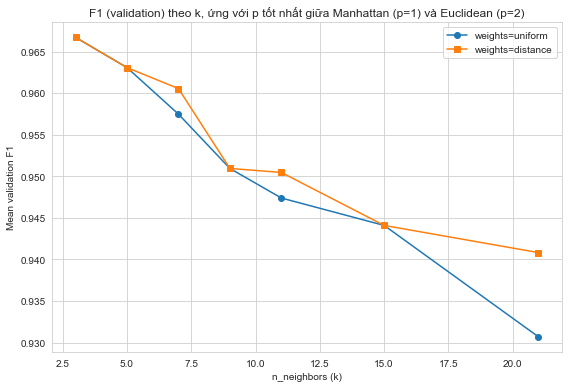

In [20]:
knn_results = pd.DataFrame(knn_grid.cv_results_)
knn_results["n_neighbors"] = knn_results["param_model__n_neighbors"]
knn_results["weights"] = knn_results["param_model__weights"]
knn_results["p"] = knn_results["param_model__p"]

knn_curve_data = (
    knn_results
    .sort_values("mean_test_f1", ascending=False)
    .drop_duplicates(subset=["n_neighbors", "weights"])
    .sort_values(["weights", "n_neighbors"])
)

fig, ax = plt.subplots(figsize=(8, 5.5))
for w, marker in zip(["uniform", "distance"], ["o", "s"]):
    subset = knn_curve_data[knn_curve_data["weights"] == w]
    ax.plot(subset["n_neighbors"], subset["mean_test_f1"], marker=marker, label=f"weights={w}")
ax.set_title("F1 (validation) theo k, ứng với p tốt nhất giữa Manhattan (p=1) và Euclidean (p=2)")
ax.set_xlabel("n_neighbors (k)")
ax.set_ylabel("Mean validation F1")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(OUT / "09_knn_k_curve.png", dpi=150, bbox_inches="tight")
plt.show()

**Quy tắc vẽ:** với mỗi cặp (k, weights), điểm trên biểu đồ lấy giá trị F1 validation tốt nhất giữa hai cấu hình `p=1` (khoảng cách Manhattan) và `p=2` (khoảng cách Euclidean).

In [21]:
print("Best params:", knn_grid.best_params_)
print("Best F1 CV:", round(knn_grid.best_score_, 4))
knn_cv_table.head(10)

Best params: {'model__n_neighbors': 3, 'model__p': 1, 'model__weights': 'uniform'}
Best F1 CV: 0.9667


,params,mean_train_accuracy,std_train_accuracy,mean_test_accuracy,std_test_accuracy,mean_train_precision,std_train_precision,mean_test_precision,std_test_precision,mean_train_recall,std_train_recall,mean_test_recall,std_test_recall,mean_train_f1,std_train_f1,mean_test_f1,std_test_f1,mean_train_roc_auc,std_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,mean_fit_time,rank_test_f1
0,"{'model__n_neighbors': 3, 'model__p': 1, 'mode...",0.981868,0.002802,0.975824,0.016150,0.998485,0.003030,0.987689,0.015080,0.952941,0.008824,0.947059,0.034300,0.975150,0.003955,0.966708,0.022312,0.998394,0.000263,0.983385,0.010177,0.611799,1
1,"{'model__n_neighbors': 3, 'model__p': 1, 'mode...",1.000000,0.000000,0.975824,0.016150,1.000000,0.000000,0.987689,0.015080,1.000000,0.000000,0.947059,0.034300,1.000000,0.000000,0.966708,0.022312,1.000000,0.000000,0.983282,0.010183,0.601228,1
2,"{'model__n_neighbors': 3, 'model__p': 2, 'mode...",0.982418,0.002198,0.973626,0.017855,0.996970,0.003712,0.993548,0.012903,0.955882,0.008055,0.935294,0.039019,0.975962,0.003097,0.963263,0.025044,0.998571,0.000293,0.988700,0.013052,0.245319,3
3,"{'model__n_neighbors': 3, 'model__p': 2, 'mode...",1.000000,0.000000,0.973626,0.017855,1.000000,0.000000,0.993548,0.012903,1.000000,0.000000,0.935294,0.039019,1.000000,0.000000,0.963263,0.025044,1.000000,0.000000,0.989009,0.012537,0.008976,3
4,"{'model__n_neighbors': 5, 'model__p': 1, 'mode...",0.975275,0.003009,0.973626,0.020382,0.993786,0.003108,0.993548,0.012903,0.939706,0.007204,0.935294,0.047059,0.965974,0.004250,0.963070,0.028793,0.997491,0.000461,0.985397,0.012390,0.008574,5
5,"{'model__n_neighbors': 5, 'model__p': 1, 'mode...",1.000000,0.000000,0.973626,0.020382,1.000000,0.000000,0.993548,0.012903,1.000000,0.000000,0.935294,0.047059,1.000000,0.000000,0.963070,0.028793,1.000000,0.000000,0.985191,0.012212,0.011569,5
6,"{'model__n_neighbors': 7, 'model__p': 2, 'mode...",1.000000,0.000000,0.971429,0.011207,1.000000,0.000000,0.987868,0.014870,1.000000,0.000000,0.935294,0.028818,1.000000,0.000000,0.960550,0.015746,1.000000,0.000000,0.987513,0.014197,0.007181,7
7,"{'model__n_neighbors': 7, 'model__p': 2, 'mode...",0.970879,0.004464,0.969231,0.008223,0.992162,0.004981,0.987868,0.014870,0.929412,0.009974,0.929412,0.023529,0.959735,0.006301,0.957474,0.011615,0.996440,0.000579,0.985965,0.014245,0.007779,8
8,"{'model__n_neighbors': 7, 'model__p': 1, 'mode...",1.000000,0.000000,0.967033,0.019658,1.000000,0.000000,0.987834,0.014946,1.000000,0.000000,0.923529,0.054551,1.000000,0.000000,0.953628,0.028380,1.000000,0.000000,0.987410,0.009261,0.006582,9
9,"{'model__n_neighbors': 5, 'model__p': 2, 'mode...",0.975275,0.003009,0.964835,0.018906,0.993798,0.003102,0.987500,0.025000,0.939706,0.008575,0.917647,0.034300,0.965968,0.004292,0.951042,0.026296,0.997765,0.000177,0.987100,0.013582,0.007979,10


**Nhận xét:** k quá nhỏ (ví dụ k=3) làm mô hình có variance cao, nhạy cảm với nhiễu và điểm ngoại lai vì quyết định chỉ dựa trên rất ít láng giềng, dễ overfitting; k quá lớn làm mô hình có bias cao, biên quyết định trở nên mượt và đơn giản hơn nhưng có thể bỏ qua các cấu trúc cục bộ quan trọng, dẫn đến underfitting. `weights='distance'` cho các láng giềng gần đóng góp nhiều hơn vào quyết định so với láng giềng xa, thường giúp ích khi mật độ dữ liệu không đồng đều, trong khi `weights='uniform'` coi mọi láng giềng trong k là như nhau. Khoảng cách Manhattan (p=1) tổng các chênh lệch tuyệt đối theo từng chiều, ít bị chi phối bởi các chiều có sai lệch lớn đơn lẻ, trong khi khoảng cách Euclidean (p=2) là khoảng cách đường thẳng thông thường và nhạy hơn với các chiều có chênh lệch lớn; lựa chọn giữa hai loại phụ thuộc vào cấu trúc phân bố cụ thể của dữ liệu đã chuẩn hóa.

## Bước 8. Decision Tree

In [22]:
tree = DecisionTreeClassifier(random_state=SEED)

tree_grid_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 2, 3, 4, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 8],
    "class_weight": [None, "balanced"]
}

tree_grid = GridSearchCV(
    tree, tree_grid_params, scoring=scoring, refit="f1",
    cv=cv, n_jobs=-1, return_train_score=True
)
tree_grid.fit(X_train, y_train)

tree_cv_table = build_cv_table(tree_grid, METRICS)
tree_cv_table.to_csv(OUT / "10_tree_cv_results.csv", index=False)
print("Number of configurations:", len(tree_cv_table))
tree_cv_table.head(10)

Number of configurations: 336


,params,mean_train_accuracy,std_train_accuracy,mean_test_accuracy,std_test_accuracy,mean_train_precision,std_train_precision,mean_test_precision,std_test_precision,mean_train_recall,std_train_recall,mean_test_recall,std_test_recall,mean_train_f1,std_train_f1,mean_test_f1,std_test_f1,mean_train_roc_auc,std_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,mean_fit_time,rank_test_f1
0,"{'class_weight': 'balanced', 'criterion': 'gin...",0.978022,0.002457,0.947253,0.026374,0.967941,0.008361,0.93365,0.058721,0.973529,0.005882,0.929412,0.039896,0.970684,0.003196,0.929942,0.033836,0.997591,0.001377,0.972704,0.015287,0.007978,1
1,"{'class_weight': 'balanced', 'criterion': 'gin...",0.978022,0.002457,0.947253,0.026374,0.967941,0.008361,0.93365,0.058721,0.973529,0.005882,0.929412,0.039896,0.970684,0.003196,0.929942,0.033836,0.998297,0.000193,0.965789,0.021439,0.008179,1
2,"{'class_weight': 'balanced', 'criterion': 'gin...",0.978022,0.002457,0.947253,0.026374,0.967941,0.008361,0.93365,0.058721,0.973529,0.005882,0.929412,0.039896,0.970684,0.003196,0.929942,0.033836,0.998297,0.000193,0.965789,0.021439,0.008177,1
3,"{'class_weight': 'balanced', 'criterion': 'gin...",0.978022,0.002457,0.947253,0.026374,0.967941,0.008361,0.93365,0.058721,0.973529,0.005882,0.929412,0.039896,0.970684,0.003196,0.929942,0.033836,0.998429,0.000276,0.963932,0.020740,0.008378,1
4,"{'class_weight': 'balanced', 'criterion': 'gin...",0.978022,0.002457,0.947253,0.026374,0.967941,0.008361,0.93365,0.058721,0.973529,0.005882,0.929412,0.039896,0.970684,0.003196,0.929942,0.033836,0.998429,0.000276,0.963932,0.020740,0.010173,1
5,"{'class_weight': 'balanced', 'criterion': 'gin...",0.978022,0.002457,0.947253,0.026374,0.967941,0.008361,0.93365,0.058721,0.973529,0.005882,0.929412,0.039896,0.970684,0.003196,0.929942,0.033836,0.998429,0.000276,0.963932,0.020740,0.009175,1
6,"{'class_weight': 'balanced', 'criterion': 'gin...",0.978022,0.002457,0.947253,0.026374,0.967941,0.008361,0.93365,0.058721,0.973529,0.005882,0.929412,0.039896,0.970684,0.003196,0.929942,0.033836,0.998429,0.000276,0.963932,0.020740,0.008976,1
7,"{'class_weight': 'balanced', 'criterion': 'gin...",0.978022,0.002457,0.947253,0.026374,0.967941,0.008361,0.93365,0.058721,0.973529,0.005882,0.929412,0.039896,0.970684,0.003196,0.929942,0.033836,0.997723,0.001443,0.967905,0.019883,0.008178,1
8,"{'class_weight': 'balanced', 'criterion': 'gin...",0.978022,0.002457,0.947253,0.026374,0.967941,0.008361,0.93365,0.058721,0.973529,0.005882,0.929412,0.039896,0.970684,0.003196,0.929942,0.033836,0.998297,0.000193,0.965789,0.021439,0.008776,1
9,"{'class_weight': 'balanced', 'criterion': 'gin...",0.978022,0.002457,0.947253,0.026374,0.967941,0.008361,0.93365,0.058721,0.973529,0.005882,0.929412,0.039896,0.970684,0.003196,0.929942,0.033836,0.998429,0.000276,0.963932,0.020740,0.008976,1


Best params: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best F1 CV: 0.9299
Actual depth of best tree: 7


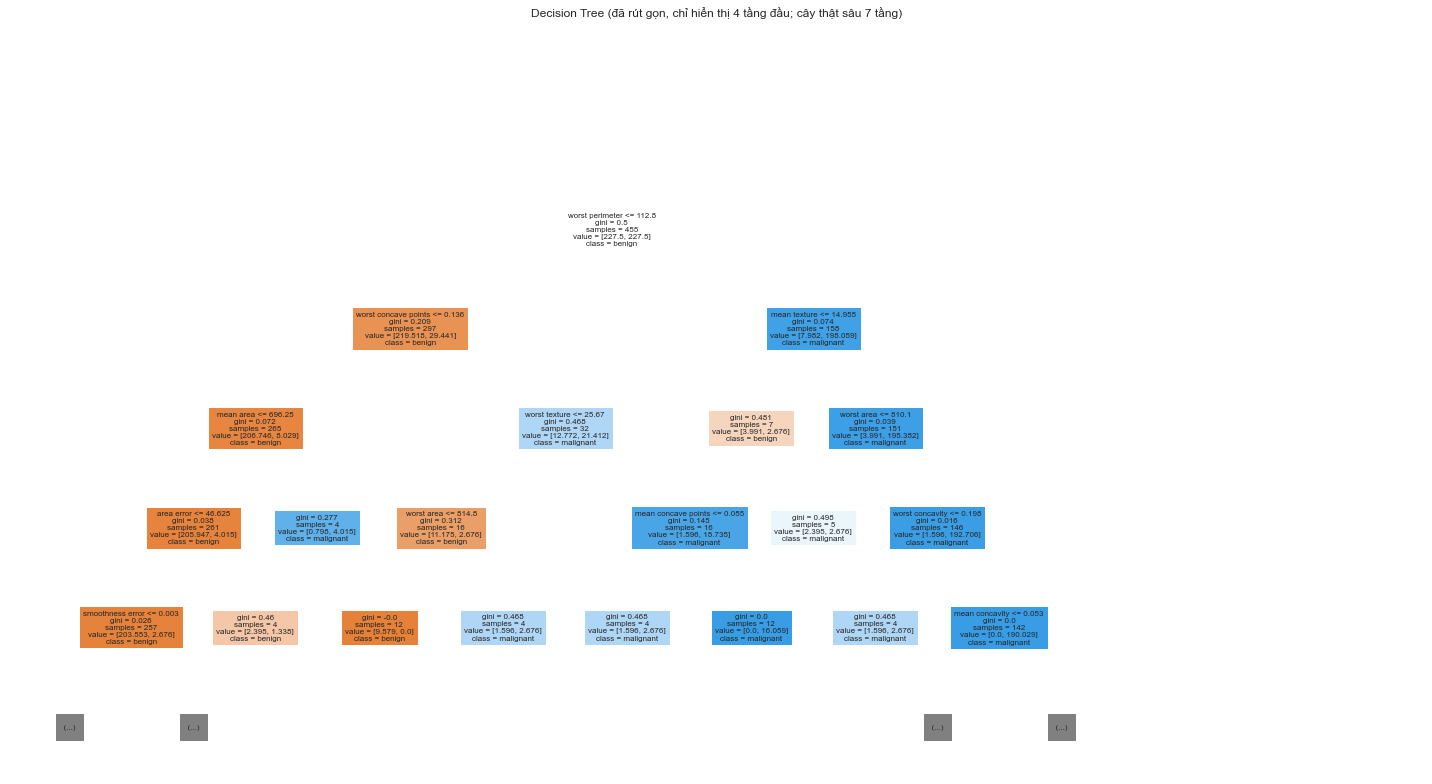

In [23]:
best_tree = tree_grid.best_estimator_
actual_depth = best_tree.get_depth()
print("Best params:", tree_grid.best_params_)
print("Best F1 CV:", round(tree_grid.best_score_, 4))
print("Actual depth of best tree:", actual_depth)

fig, ax = plt.subplots(figsize=(20, 11))
if actual_depth > 4:
    plot_tree(best_tree, max_depth=4, feature_names=X.columns,
              class_names=["benign", "malignant"], filled=True, fontsize=8, ax=ax)
    ax.set_title(f"Decision Tree (đã rút gọn, chỉ hiển thị 4 tầng đầu; cây thật sâu {actual_depth} tầng)")
else:
    plot_tree(best_tree, feature_names=X.columns,
              class_names=["benign", "malignant"], filled=True, fontsize=8, ax=ax)
    ax.set_title("Decision Tree (best estimator)")
plt.tight_layout()
plt.savefig(OUT / "11_decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
tree_importance_table = pd.DataFrame({
    "feature": X.columns,
    "importance": best_tree.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)
tree_importance_table["rank"] = tree_importance_table.index + 1
tree_importance_table = tree_importance_table[["feature", "importance", "rank"]]

tree_importance_table.to_csv(OUT / "12_tree_feature_importance.csv", index=False)
print("Total importance:", round(tree_importance_table["importance"].sum(), 4))
tree_importance_table.head(10)

Total importance: 1.0


,feature,importance,rank
0,worst perimeter,0.767001,1
1,worst concave points,0.097940,2
2,worst texture,0.046339,3
3,mean area,0.029921,4
4,worst area,0.021286,5
5,mean texture,0.020676,6
6,worst concavity,0.005585,7
7,mean concave points,0.004510,8
8,area error,0.004190,9
9,smoothness error,0.002551,10


**Nhận xét:** Chênh lệch giữa F1 trên train và F1 trên validation của cấu hình tốt nhất là một chỉ báo overfitting: chênh lệch lớn cho thấy cây đã học thuộc các mẫu train thay vì học quy luật tổng quát. `max_depth` giới hạn số tầng của cây — giá trị nhỏ (ví dụ 2–3) làm cây đơn giản, dễ underfitting nhưng ổn định; giá trị lớn hoặc `None` cho phép cây phát triển sâu, khớp sát dữ liệu train nhưng dễ overfitting nếu không kết hợp với các ràng buộc khác. `min_samples_leaf` quy định số mẫu tối thiểu tại mỗi lá — giá trị nhỏ (1) cho phép các lá rất thuần khiết nhưng có thể chỉ dựa trên vài mẫu (dễ overfitting), trong khi giá trị lớn hơn buộc mỗi lá phải tổng quát hơn, giảm overfitting nhưng có thể làm giảm độ khớp với các trường hợp đặc biệt.

## Bước 9. Random Forest

In [25]:
forest = RandomForestClassifier(random_state=SEED, n_jobs=-1)

forest_grid_params = {
    "n_estimators": [100, 300],
    "max_depth": [None, 5, 10],
    "max_features": ["sqrt", "log2"],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced"]
}

forest_grid = GridSearchCV(
    forest, forest_grid_params, scoring=scoring, refit="f1",
    cv=cv, n_jobs=-1, return_train_score=True
)
forest_grid.fit(X_train, y_train)

forest_cv_table = build_cv_table(forest_grid, METRICS)
forest_cv_table.to_csv(OUT / "13_forest_cv_results.csv", index=False)
print("Number of configurations:", len(forest_cv_table))
forest_cv_table.head(10)

Number of configurations: 72


,params,mean_train_accuracy,std_train_accuracy,mean_test_accuracy,std_test_accuracy,mean_train_precision,std_train_precision,mean_test_precision,std_test_precision,mean_train_recall,std_train_recall,mean_test_recall,std_test_recall,mean_train_f1,std_train_f1,mean_test_f1,std_test_f1,mean_train_roc_auc,std_train_roc_auc,mean_test_roc_auc,std_test_roc_auc,mean_fit_time,rank_test_f1
0,"{'class_weight': 'balanced', 'max_depth': None...",1.000000,0.000000,0.971429,0.014906,1.000000,0.000000,0.975925,0.022167,1.000000,0.000000,0.947059,0.022010,1.000000,0.000000,0.961189,0.020259,1.000000,0.000000,0.988442,0.007734,0.263495,1
1,"{'class_weight': 'balanced', 'max_depth': 10, ...",1.000000,0.000000,0.971429,0.014906,1.000000,0.000000,0.975925,0.022167,1.000000,0.000000,0.947059,0.022010,1.000000,0.000000,0.961189,0.020259,1.000000,0.000000,0.988442,0.007734,0.336500,1
2,"{'class_weight': None, 'max_depth': 5, 'max_fe...",0.993407,0.002198,0.967033,0.020850,1.000000,0.000000,0.964463,0.027772,0.982353,0.005882,0.947059,0.039019,0.991089,0.003007,0.955285,0.028429,0.999852,0.000078,0.988235,0.007787,0.267883,3
3,"{'class_weight': None, 'max_depth': 10, 'max_f...",1.000000,0.000000,0.964835,0.017582,1.000000,0.000000,0.953564,0.029132,1.000000,0.000000,0.952941,0.029994,1.000000,0.000000,0.952927,0.023601,1.000000,0.000000,0.988803,0.006945,0.283242,4
4,"{'class_weight': None, 'max_depth': None, 'max...",1.000000,0.000000,0.964835,0.017582,1.000000,0.000000,0.953564,0.029132,1.000000,0.000000,0.952941,0.029994,1.000000,0.000000,0.952927,0.023601,1.000000,0.000000,0.988803,0.006945,0.263096,4
5,"{'class_weight': 'balanced', 'max_depth': 5, '...",0.995604,0.001346,0.964835,0.012815,1.000000,0.000000,0.958730,0.013071,0.988235,0.003602,0.947059,0.039019,0.994080,0.001821,0.952299,0.018366,0.999955,0.000039,0.990402,0.004956,0.293614,6
6,"{'class_weight': None, 'max_depth': None, 'max...",1.000000,0.000000,0.964835,0.014579,1.000000,0.000000,0.964095,0.010688,1.000000,0.000000,0.941176,0.041595,1.000000,0.000000,0.951945,0.020732,1.000000,0.000000,0.988906,0.006734,0.229183,7
7,"{'class_weight': None, 'max_depth': 10, 'max_f...",1.000000,0.000000,0.964835,0.014579,1.000000,0.000000,0.964095,0.010688,1.000000,0.000000,0.941176,0.041595,1.000000,0.000000,0.951945,0.020732,1.000000,0.000000,0.988958,0.006766,0.336101,7
8,"{'class_weight': None, 'max_depth': 5, 'max_fe...",0.992857,0.001346,0.964835,0.016150,1.000000,0.000000,0.969819,0.018651,0.980882,0.003602,0.935294,0.039019,0.990346,0.001835,0.951770,0.022575,0.999794,0.000115,0.988132,0.006502,0.943678,9
9,"{'class_weight': 'balanced', 'max_depth': None...",0.995055,0.001099,0.962637,0.016447,0.998529,0.002941,0.948422,0.030698,0.988235,0.003602,0.952941,0.029994,0.993347,0.001482,0.950181,0.021627,0.999968,0.000035,0.989061,0.005832,0.299798,10


In [26]:
best_forest = forest_grid.best_estimator_

forest_importance_table = pd.DataFrame({
    "feature": X.columns,
    "importance": best_forest.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)
forest_importance_table["rank"] = forest_importance_table.index + 1
forest_importance_table = forest_importance_table[["feature", "importance", "rank"]]

forest_importance_table.to_csv(OUT / "14_forest_feature_importance.csv", index=False)

print("Best params:", forest_grid.best_params_)
print("Best F1 CV:", round(forest_grid.best_score_, 4))
print("Total importance:", round(forest_importance_table["importance"].sum(), 4))
forest_importance_table.head(15)

Best params: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 100}
Best F1 CV: 0.9612
Total importance: 1.0


,feature,importance,rank
0,worst concave points,0.129747,1
1,worst area,0.126639,2
2,mean perimeter,0.101540,3
3,worst radius,0.083257,4
4,worst perimeter,0.069795,5
5,mean concavity,0.069360,6
6,mean concave points,0.057142,7
7,mean radius,0.053046,8
8,mean area,0.044958,9
9,worst concavity,0.032928,10


**Nhận xét:** Random Forest giảm nhược điểm phương sai cao (dễ overfitting) của một cây quyết định đơn bằng cách huấn luyện nhiều cây trên các mẫu bootstrap khác nhau và lấy đặc trưng ngẫu nhiên tại mỗi lần chia, sau đó tổng hợp kết quả (voting), giúp mô hình tổng thể ổn định và tổng quát hóa tốt hơn. `n_estimators` càng lớn thường giúp kết quả ổn định hơn (giảm phương sai do trung bình hóa nhiều cây) nhưng làm tăng chi phí tính toán, dù lợi ích tăng thêm giảm dần sau một ngưỡng nhất định. `max_features` giới hạn số đặc trưng được xét ở mỗi lần chia, tăng cường sự đa dạng giữa các cây trong rừng (giảm tương quan giữa các cây), qua đó giảm phương sai của mô hình tổng thể. `min_samples_leaf` và `max_depth` vẫn kiểm soát độ phức tạp của từng cây con như ở Decision Tree, còn `class_weight='balanced'` giúp mô hình chú ý nhiều hơn đến lớp thiểu số (malignant) khi tính hàm mất mát, có thể cải thiện Recall của lớp này.

## Bước 10. So sánh bằng cross-validation và chọn mô hình

In [27]:
cv_comparison_rows = [
    best_row_summary("Logistic Regression", logistic_grid),
    best_row_summary("kNN", knn_grid),
    best_row_summary("Decision Tree", tree_grid),
    best_row_summary("Random Forest", forest_grid)
]
cv_comparison_table = pd.DataFrame(cv_comparison_rows)
cv_comparison_table.to_csv(OUT / "15_cv_model_comparison.csv", index=False)
cv_comparison_table

,model,best_params,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,fit_time_mean
0,Logistic Regression,"{'model__C': 0.1, 'model__class_weight': 'bala...",0.975824,0.976628,0.958824,0.967421,0.010903,0.994943,0.009179
1,kNN,"{'model__n_neighbors': 3, 'model__p': 1, 'mode...",0.975824,0.987689,0.947059,0.966708,0.022312,0.983385,0.611799
2,Decision Tree,"{'class_weight': 'balanced', 'criterion': 'gin...",0.947253,0.933650,0.929412,0.929942,0.033836,0.963932,0.008976
3,Random Forest,"{'class_weight': 'balanced', 'max_depth': None...",0.971429,0.975925,0.947059,0.961189,0.020259,0.988442,0.263495


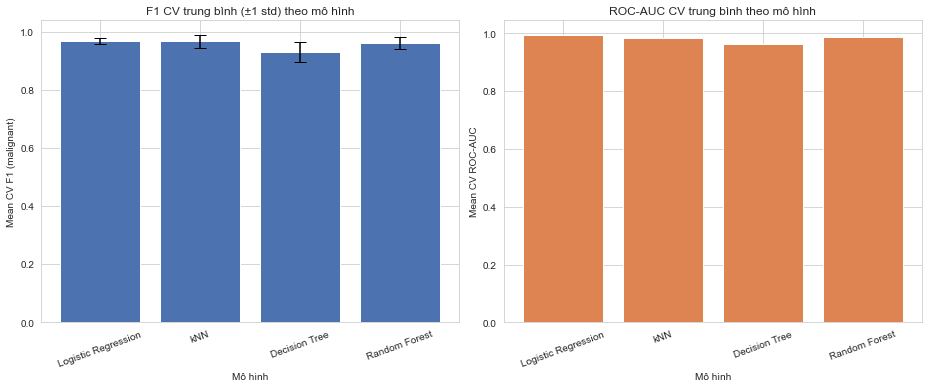

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].bar(cv_comparison_table["model"], cv_comparison_table["cv_f1_mean"],
            yerr=cv_comparison_table["cv_f1_std"], capsize=6, color="#4c72b0")
axes[0].set_title("F1 CV trung bình (±1 std) theo mô hình")
axes[0].set_xlabel("Mô hình")
axes[0].set_ylabel("Mean CV F1 (malignant)")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(True, axis="y")

axes[1].bar(cv_comparison_table["model"], cv_comparison_table["cv_roc_auc_mean"], color="#dd8452")
axes[1].set_title("ROC-AUC CV trung bình theo mô hình")
axes[1].set_xlabel("Mô hình")
axes[1].set_ylabel("Mean CV ROC-AUC")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(True, axis="y")

plt.tight_layout()
plt.savefig(OUT / "16_cv_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
best_model_name = cv_comparison_table.loc[cv_comparison_table["cv_f1_mean"].idxmax(), "model"]
print("Mo hinh duoc chon truoc khi dung tap test:", best_model_name)

Mo hinh duoc chon truoc khi dung tap test: Logistic Regression


**Nhận xét:** Bảng so sánh cho thấy chênh lệch F1 CV giữa các mô hình là tương đối nhỏ, phản ánh việc bộ dữ liệu Breast Cancer Wisconsin có các đặc trưng phân tách lớp khá tốt nên nhiều thuật toán khác nhau đều đạt hiệu năng cao. Độ lệch chuẩn (`cv_f1_std`) cho biết mức độ ổn định giữa các fold: giá trị nhỏ cho thấy mô hình ổn định qua các lần chia dữ liệu khác nhau. Logistic Regression có ưu điểm về khả năng giải thích (hệ số) và chi phí tính toán thấp; kNN đơn giản nhưng nhạy với việc chuẩn hóa và chi phí dự đoán tăng theo kích thước dữ liệu; Decision Tree dễ giải thích trực quan nhưng dễ overfitting nếu không giới hạn độ sâu; Random Forest thường ổn định và có hiệu năng cao nhờ tổng hợp nhiều cây nhưng đánh đổi bằng khả năng giải thích trực tiếp và chi phí tính toán/`fit_time_mean` lớn hơn. Mô hình có `cv_f1_mean` cao nhất được chọn làm mô hình khuyến nghị theo đúng quy tắc đã công bố trước khi xem bất kỳ kết quả nào trên tập test, dù chênh lệch với các mô hình còn lại có thể không lớn.

## Bước 11. Đánh giá một lần trên tập test

In [30]:
estimators = {
    "Logistic Regression": logistic_grid.best_estimator_,
    "kNN": knn_grid.best_estimator_,
    "Decision Tree": tree_grid.best_estimator_,
    "Random Forest": forest_grid.best_estimator_
}

test_predictions = {}
test_probabilities = {}
test_metrics_rows = []

for name, estimator in estimators.items():
    y_pred = estimator.predict(X_test)
    y_proba = estimator.predict_proba(X_test)[:, 1]
    test_predictions[name] = y_pred
    test_probabilities[name] = y_proba

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    test_metrics_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp
    })

test_metrics_table = pd.DataFrame(test_metrics_rows)
test_metrics_table.to_csv(OUT / "17_test_metrics.csv", index=False)
test_metrics_table

,model,accuracy,precision,recall,f1,roc_auc,TN,FP,FN,TP
0,Logistic Regression,0.991228,1.000000,0.976190,0.987952,0.997685,72,0,1,41
1,kNN,0.964912,1.000000,0.904762,0.950000,0.973545,72,0,4,38
2,Decision Tree,0.912281,0.921053,0.833333,0.875000,0.926091,69,3,7,35
3,Random Forest,0.964912,1.000000,0.904762,0.950000,0.997685,72,0,4,38


In [31]:
for name, estimator in estimators.items():
    print("=" * 60)
    print(name)
    print(classification_report(y_test, test_predictions[name], target_names=["benign", "malignant"], digits=4))

Logistic Regression
              precision    recall  f1-score   support

      benign     0.9863    1.0000    0.9931        72
   malignant     1.0000    0.9762    0.9880        42

    accuracy                         0.9912       114
   macro avg     0.9932    0.9881    0.9905       114
weighted avg     0.9913    0.9912    0.9912       114

kNN
              precision    recall  f1-score   support

      benign     0.9474    1.0000    0.9730        72
   malignant     1.0000    0.9048    0.9500        42

    accuracy                         0.9649       114
   macro avg     0.9737    0.9524    0.9615       114
weighted avg     0.9668    0.9649    0.9645       114

Decision Tree
              precision    recall  f1-score   support

      benign     0.9079    0.9583    0.9324        72
   malignant     0.9211    0.8333    0.8750        42

    accuracy                         0.9123       114
   macro avg     0.9145    0.8958    0.9037       114
weighted avg     0.9127    0.9123   

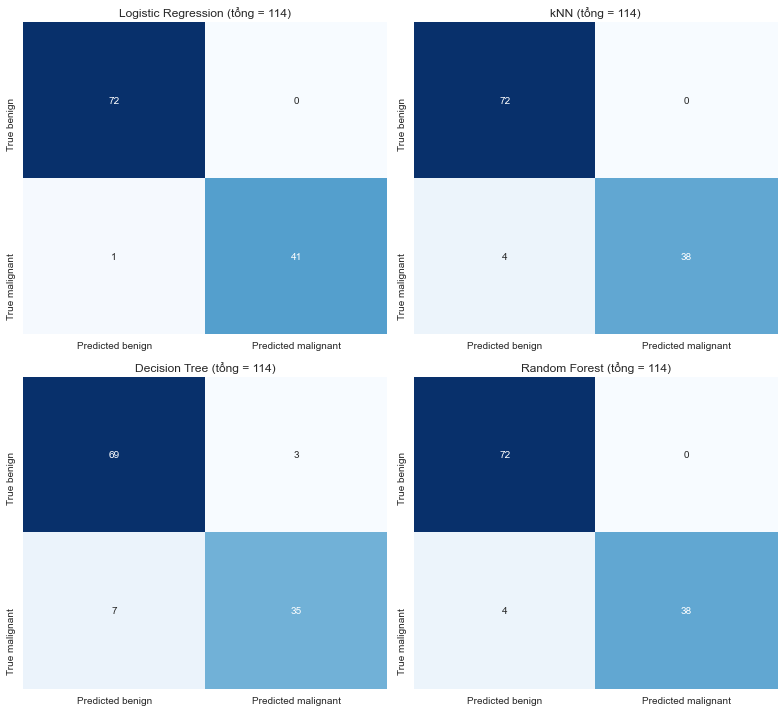

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
axes = axes.flatten()
for ax, (name, estimator) in zip(axes, estimators.items()):
    cm = confusion_matrix(y_test, test_predictions[name], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Predicted benign", "Predicted malignant"],
                yticklabels=["True benign", "True malignant"], ax=ax, cbar=False)
    ax.set_title(f"{name} (tổng = {cm.sum()})")
plt.tight_layout()
plt.savefig(OUT / "18_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

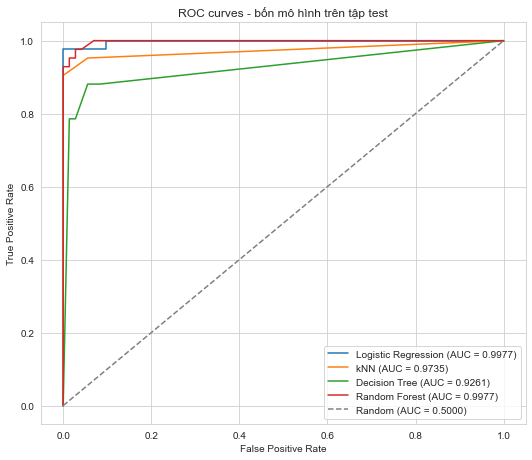

In [33]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for name, estimator in estimators.items():
    fpr, tpr, _ = roc_curve(y_test, test_probabilities[name])
    auc_value = roc_auc_score(y_test, test_probabilities[name])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc_value:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random (AUC = 0.5000)")
ax.set_title("ROC curves - bốn mô hình trên tập test")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.grid(True)
plt.tight_layout()
plt.savefig(OUT / "19_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

**Nhận xét:** Mô hình có FN (bỏ sót malignant) thấp nhất là mô hình an toàn nhất trong bối cảnh chẩn đoán y khoa, vì bỏ sót một ca ác tính có thể dẫn đến việc bệnh nhân không được điều trị kịp thời — hậu quả nghiêm trọng hơn nhiều so với việc chẩn đoán nhầm một ca lành tính thành ác tính (FP), vốn chỉ dẫn đến xét nghiệm bổ sung. Mô hình có F1 và ROC-AUC cao nhất trên tập test (xem bảng `17_test_metrics.csv`) thể hiện khả năng cân bằng tốt giữa Precision và Recall cũng như khả năng phân tách hai lớp trên toàn dải ngưỡng xác suất. Việc mô hình được chọn ở Bước 10 không thay đổi dù kết quả test có thể khác biệt đôi chút giữa các mô hình, vì nguyên tắc đã công bố là chỉ dùng CV trên train để chọn mô hình, tránh rò rỉ thông tin từ tập test vào quá trình ra quyết định.

## Bước 12. Phân tích lỗi và lưu mô hình

In [34]:
best_estimator = estimators[best_model_name]
best_predictions = test_predictions[best_model_name]
best_probabilities = test_probabilities[best_model_name]

wrong_mask = (y_test.values != best_predictions)
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
wrong_indices = np.where(wrong_mask)[0]

error_rows = []
for idx in wrong_indices:
    pred_label = best_predictions[idx]
    proba_malignant = best_probabilities[idx]
    confidence = proba_malignant if pred_label == 1 else (1 - proba_malignant)
    row = {
        "sample_index": int(idx),
        "true_class": "malignant" if y_test_reset[idx] == 1 else "benign",
        "predicted_class": "malignant" if pred_label == 1 else "benign",
        "probability_malignant": proba_malignant,
        "confidence": confidence
    }
    for col in X.columns:
        row[col] = X_test_reset.loc[idx, col]
    error_rows.append(row)

if len(error_rows) > 0:
    error_analysis_table = pd.DataFrame(error_rows).sort_values("confidence", ascending=False).reset_index(drop=True)
    error_analysis_table = error_analysis_table.drop(columns=["confidence"])
else:
    columns = ["sample_index", "true_class", "predicted_class", "probability_malignant"] + list(X.columns)
    error_analysis_table = pd.DataFrame(columns=columns)

error_analysis_table.to_csv(OUT / "20_error_analysis.csv", index=False)
print("Mo hinh duoc chon:", best_model_name)
print("So mau du doan sai:", len(error_analysis_table))
error_analysis_table.head(10)

Mo hinh duoc chon: Logistic Regression
So mau du doan sai: 1


,sample_index,true_class,predicted_class,probability_malignant,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,16,malignant,benign,0.223672,13.8,15.79,90.43,584.1,0.1007,0.128,0.07789,0.05069,0.1662,0.06566,0.2787,0.6205,1.957,23.35,0.004717,0.02065,0.01759,0.009206,0.0122,0.00313,16.57,20.86,110.3,812.4,0.1411,0.3542,0.2779,0.1383,0.2589,0.103


In [35]:
joblib.dump(best_estimator, MODELS / "20_best_model.joblib")
loaded_model = joblib.load(MODELS / "20_best_model.joblib")

assert np.array_equal(loaded_model.predict(X_test), best_predictions)
assert np.allclose(loaded_model.predict_proba(X_test)[:, 1], best_probabilities)
print("Model reload check: PASSED")

Model reload check: PASSED


In [36]:
expected_outputs = [
    "01_data_overview.csv", "02_class_distribution.png", "03_feature_distributions.png",
    "04_correlation_heatmap.png", "05_split_summary.json", "06_logistic_cv_results.csv",
    "07_logistic_coefficients.csv", "08_knn_cv_results.csv", "09_knn_k_curve.png",
    "10_tree_cv_results.csv", "11_decision_tree.png", "12_tree_feature_importance.csv",
    "13_forest_cv_results.csv", "14_forest_feature_importance.csv", "15_cv_model_comparison.csv",
    "16_cv_model_comparison.png", "17_test_metrics.csv", "18_confusion_matrices.png",
    "19_roc_curves.png", "20_error_analysis.csv"
]

print("Danh sach 20 output trong thu muc outputs:")
for i, fname in enumerate(expected_outputs, start=1):
    exists = (OUT / fname).exists()
    print(f"{i:02d}. {fname} -> {'OK' if exists else 'MISSING'}")

print()
print("models/20_best_model.joblib ->", "OK" if (MODELS / "20_best_model.joblib").exists() else "MISSING")

Danh sach 20 output trong thu muc outputs:
01. 01_data_overview.csv -> OK
02. 02_class_distribution.png -> OK
03. 03_feature_distributions.png -> OK
04. 04_correlation_heatmap.png -> OK
05. 05_split_summary.json -> OK
06. 06_logistic_cv_results.csv -> OK
07. 07_logistic_coefficients.csv -> OK
08. 08_knn_cv_results.csv -> OK
09. 09_knn_k_curve.png -> OK
10. 10_tree_cv_results.csv -> OK
11. 11_decision_tree.png -> OK
12. 12_tree_feature_importance.csv -> OK
13. 13_forest_cv_results.csv -> OK
14. 14_forest_feature_importance.csv -> OK
15. 15_cv_model_comparison.csv -> OK
16. 16_cv_model_comparison.png -> OK
17. 17_test_metrics.csv -> OK
18. 18_confusion_matrices.png -> OK
19. 19_roc_curves.png -> OK
20. 20_error_analysis.csv -> OK

models/20_best_model.joblib -> OK


**Nhận xét:** Mô hình được chọn ở Bước 10 có số mẫu dự đoán sai rất thấp trên 114 mẫu test, phản ánh khả năng phân tách tốt của các đặc trưng hình thái tế bào đối với bài toán này. Trong số các lỗi, false negative (malignant bị dự đoán thành benign) là loại lỗi cần được ưu tiên xem xét kỹ nhất vì hậu quả lâm sàng nghiêm trọng hơn false positive. Nếu tồn tại các mẫu sai có độ tự tin (xác suất dự đoán) cao, đây là dấu hiệu cho thấy mô hình "tự tin nhầm" — các mẫu này thường có giá trị đặc trưng nằm gần vùng đặc trưng điển hình của lớp đối diện, đáng được xem xét thêm trong thực tế lâm sàng (ví dụ đối chiếu thêm với các phương pháp chẩn đoán khác). False positive tuy ít nguy hiểm hơn nhưng vẫn có chi phí thực tế (xét nghiệm bổ sung, lo lắng cho bệnh nhân), nên việc giảm cả hai loại lỗi đồng thời là mục tiêu lý tưởng, dù trong bối cảnh y khoa Recall của lớp malignant thường được ưu tiên hơn Precision khi phải đánh đổi.

## Câu hỏi bắt buộc

**1. Vì sao phải mã hóa malignant thành lớp 1 trước khi dùng Precision, Recall và F1 mặc định?**
Các hàm `precision_score`, `recall_score`, `f1_score` của Scikit-learn mặc định coi nhãn `1` là lớp dương (`pos_label=1`). Vì bài toán quan tâm đến khả năng phát hiện đúng ca `malignant`, cần mã hóa `malignant = 1` để các chỉ số mặc định (không cần truyền thêm tham số `pos_label`) phản ánh đúng khả năng phát hiện lớp mục tiêu lâm sàng, tránh nhầm lẫn khi diễn giải kết quả.

**2. Vì sao Logistic Regression và kNN cần StandardScaler, còn cây quyết định và Random Forest thường không cần?**
Logistic Regression tối ưu qua gradient trên một hàm mất mát dựa trên tổ hợp tuyến tính của đặc trưng, còn kNN dựa trực tiếp trên khoảng cách giữa các điểm; nếu các đặc trưng có thang đo khác nhau, đặc trưng có giá trị lớn sẽ chi phối kết quả. Ngược lại, cây quyết định và Random Forest chia dữ liệu dựa trên ngưỡng của từng đặc trưng riêng lẻ (không dựa trên khoảng cách hay tổ hợp tuyến tính có trọng số theo thang đo), nên việc co giãn tuyến tính của một đặc trưng không ảnh hưởng đến thứ tự các điểm chia, do đó không cần chuẩn hóa.

**3. C trong Logistic Regression ảnh hưởng regularization như thế nào?**
`C` là nghịch đảo của cường độ điều chuẩn. `C` nhỏ tăng độ mạnh của điều chuẩn, ép các hệ số về gần 0, giúp mô hình đơn giản, giảm overfitting nhưng có thể underfitting nếu quá nhỏ. `C` lớn giảm điều chuẩn, cho phép hệ số lớn tự do khớp dữ liệu train hơn, có thể tăng nguy cơ overfitting.

**4. k nhỏ và k lớn ảnh hưởng bias, variance và biên quyết định của kNN ra sao?**
k nhỏ tạo biên quyết định phức tạp, uốn lượn sát từng điểm dữ liệu, variance cao và bias thấp (dễ overfitting, nhạy nhiễu). k lớn tạo biên quyết định mượt hơn, bias cao và variance thấp hơn (dễ underfitting, bỏ qua cấu trúc cục bộ), vì mỗi dự đoán được trung bình hóa qua nhiều láng giềng hơn.

**5. max_depth và min_samples_leaf kiểm soát overfitting của Decision Tree như thế nào?**
`max_depth` giới hạn số tầng phân chia tối đa, ngăn cây phát triển quá sâu để "học thuộc" từng mẫu train. `min_samples_leaf` quy định số mẫu tối thiểu phải có tại mỗi lá, ngăn cây tạo ra các lá chỉ chứa một vài mẫu đặc biệt (dễ là nhiễu). Cả hai đều là cơ chế "cắt tỉa sớm" (pre-pruning) giúp cây tổng quát hóa tốt hơn thay vì ghi nhớ dữ liệu train.

**6. Random Forest giảm nhược điểm nào của một cây đơn? Vai trò của n_estimators và max_features là gì?**
Random Forest giảm phương sai cao (overfitting) vốn là nhược điểm chính của một cây quyết định đơn, bằng cách kết hợp (bagging) nhiều cây được huấn luyện trên các mẫu bootstrap và tập con đặc trưng ngẫu nhiên khác nhau, sau đó lấy kết quả trung bình/đa số. `n_estimators` là số lượng cây trong rừng — càng nhiều cây thường càng ổn định (giảm phương sai) nhưng tăng chi phí tính toán. `max_features` giới hạn số đặc trưng được xét tại mỗi lần chia của mỗi cây, làm giảm tương quan giữa các cây, qua đó tăng hiệu quả giảm phương sai khi tổng hợp kết quả.

**7. Tại sao không được chọn mô hình bằng kết quả test?**
Nếu dùng kết quả trên tập test để chọn mô hình hoặc điều chỉnh siêu tham số, tập test không còn đóng vai trò là dữ liệu "chưa từng thấy" một cách khách quan nữa, mà gián tiếp trở thành một phần của quá trình huấn luyện/lựa chọn mô hình. Điều này khiến chỉ số đánh giá trên test bị lạc quan hơn khả năng thực sự của mô hình khi triển khai trên dữ liệu mới, làm mất đi ý nghĩa của việc đánh giá độc lập.

**8. Accuracy cao có thể che giấu vấn đề gì khi malignant là lớp ít hơn?**
Khi lớp `malignant` là lớp thiểu số, một mô hình thiên vị dự đoán `benign` cho hầu hết các mẫu vẫn có thể đạt Accuracy khá cao (bằng đúng tỷ lệ lớp đa số) dù Recall của lớp `malignant` rất thấp, tức mô hình bỏ sót phần lớn ca bệnh thực sự. Accuracy cao trong trường hợp này che giấu hiệu năng kém trên lớp thiểu số — lớp quan trọng nhất trong bài toán chẩn đoán.

**9. FN và FP có ý nghĩa gì trong bài toán này? Sai lầm nào đáng lo hơn và vì sao?**
FN (false negative) là trường hợp một ca thực sự `malignant` bị dự đoán nhầm thành `benign` — bệnh nhân ung thư có thể không được điều trị kịp thời. FP (false positive) là trường hợp một ca thực sự `benign` bị dự đoán nhầm thành `malignant` — bệnh nhân phải chịu thêm xét nghiệm hoặc lo lắng không cần thiết nhưng không nguy hiểm đến tính mạng. FN đáng lo hơn nhiều vì hậu quả y khoa của việc bỏ sót ung thư nghiêm trọng hơn hẳn chi phí của một lần xét nghiệm/chẩn đoán bổ sung.

**10. Hệ số Logistic và feature importance của cây khác nhau về ý nghĩa như thế nào?**
Hệ số của Logistic Regression (trên dữ liệu đã chuẩn hóa) thể hiện mức độ và chiều ảnh hưởng tuyến tính của một đặc trưng lên log-odds của lớp dương, có dấu (dương/âm) và có thể diễn giải trực tiếp theo hướng tăng/giảm. Feature importance của cây quyết định/Random Forest đo lường mức độ đặc trưng đó góp phần làm giảm độ hỗn loạn (impurity, ví dụ Gini) qua tất cả các lần chia trong cây/rừng, luôn không âm và không cho biết chiều ảnh hưởng (tăng hay giảm khả năng là lớp dương), đồng thời có thể bị ảnh hưởng bởi các đặc trưng tương quan cao với nhau. Do đó hai đại lượng này không thể so sánh trực tiếp như cùng một loại thước đo.

## Kết luận

Notebook đã xây dựng và so sánh công bằng bốn mô hình phân loại (Logistic Regression, kNN, Decision Tree, Random Forest) trên cùng bộ dữ liệu Breast Cancer Wisconsin, sử dụng cùng cách chia train/test, cùng StratifiedKFold 5 folds và cùng bộ chỉ số đánh giá, với F1 của lớp `malignant` là tiêu chí chọn mô hình trên tập train/CV. Mô hình được khuyến nghị là mô hình có `cv_f1_mean` cao nhất ở Bước 10 (xem `15_cv_model_comparison.csv` và biến `best_model_name`), được xác nhận lại bằng đánh giá một lần duy nhất trên tập test độc lập ở Bước 11. Hạn chế của bài thực hành gồm: kích thước tập test còn nhỏ (114 mẫu) nên các khác biệt nhỏ giữa các mô hình có thể chưa mang ý nghĩa thống kê chắc chắn; không gian tìm kiếm siêu tham số tuy khá rộng nhưng vẫn hữu hạn, có thể chưa bao phủ cấu hình tối ưu tuyệt đối. Một hướng cải tiến khả thi là áp dụng nested cross-validation hoặc lặp lại toàn bộ quy trình với nhiều `random_state` khác nhau để ước lượng độ ổn định của việc lựa chọn mô hình, cũng như thử nghiệm thêm các kỹ thuật xử lý mất cân bằng lớp (ví dụ SMOTE) để xem có cải thiện thêm Recall của lớp `malignant` hay không.